# Quark-Gluons jets

This notebook is dedicated to exploring the dataset and visualizing the features to gain insights into the data distribution and relationships between variables. We will use various plotting techniques to understand the characteristics of the dataset and identify any patterns or anomalies that may be present. 

The 3 main datasets wil be:
- **Top tagging**: This dataset contains information about top quark tagging, which is a technique used in particle physics to identify top quarks in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for top quark identification.
- **Quark-gluon jet tagging**: This dataset contains information about quark-gluon jet tagging, which is a technique used to distinguish between jets originating from quarks and gluons. The features in this dataset may include various jet substructure observables and kinematic variables that are relevant for quark-gluon discrimination.
- **Higgs tagging**: This dataset contains information about Higgs boson tagging, which is a technique used to identify Higgs bosons in high-energy collisions. The features in this dataset may include various kinematic variables and jet substructure observables that are relevant for Higgs boson identification.

We can find the dataset in the following path: `../data/QG_jets_fp32_0.npz`. We use only 1 file to this exploration.

**Description taken from the original source:** [zenodo](https://zenodo.org/records/19362155) 

A `float32` (single-precision) version of the quark and gluon jet dataset originally published by Komiske, Metodiev, and Thaler (Zenodo record 3164691). Only the 20-file subset without charm and bottom quark jets is included here. All simulation parameters and jet selection criteria are identical to the original:

- Pythia 8.226, $\sqrt{s} = 14 TeV$
- Quarks from `WeakBosonAndParton:qg2gmZq`, gluons from `WeakBosonAndParton:qqbar2gmZg` with the Z decaying to neutrinos
- FastJet 3.3.0, anti-k_t jets with $R = 0.4$
- $p_T^jet \in [500, 550] GeV, |y^jet| < 1.7$

There are 20 files, each in compressed NumPy format (`QG_jets_fp32_0.npz` through `QG_jets_fp32_19.npz`). Each file contains two arrays:

- **X**: (100000, M, 4) — 50k quark and 50k gluon jets, randomly sorted, padded to max multiplicity M, with particle features (pt, rapidity, azimuthal angle, pdgid) stored as float32
- **y**: (100000,) — jet labels, gluon = 0, quark = 1
The original dataset stores X in float64. Here X has been cast to float32, approximately halving file size. The y labels are unchanged.

Komiske, Metodiev, Thaler, Energy Flow Networks: Deep Sets for Particle Jets, JHEP 01 (2019) 121, arXiv:1810.05165

In [2]:
# import libraries
import numpy as np

In [3]:
try:
    with np.load('../data/QG_jets_fp32_0.npz', 'r') as f:
        print("File keys:", list(f.keys()), "\n")

        for key in f.keys():
            print(f"Shape of '{key}': {f[key].shape}")

        X = f['X'][:]
        y = f['y'][:]
except Exception as e:
    print(f"Error loading data using numpy: {e}")

File keys: ['X', 'y'] 

Shape of 'X': (100000, 139, 4)
Shape of 'y': (100000,)


Let's see what is inside

### Data exploration

In [4]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
num_jets, max_multiplicity, num_features = X.shape

# Create jet IDs and labels for each particle
jet_ids = np.repeat(np.arange(num_jets), max_multiplicity)
labels = np.repeat(y, max_multiplicity)
# Flatten the 3D array to 2D for easier DataFrame creation
x_flat = X.reshape(-1, num_features)

# dataframe
df = pl.DataFrame(
    x_flat,
    schema=['pt', 'eta', 'phi', 'pdgid']
    ).with_columns([
    pl.Series('jet_id', jet_ids, dtype=pl.Int32),
    pl.Series('target', labels, dtype=pl.Int8)
])

df_reals = df.filter(pl.col('pt') > 0)

print(f"Total particles: {len(df)}")

Total particles: 13900000


After this first exploration we found a dataset with 13 900 000 particles in total.

In [32]:
# statistics by label
stats = df_reals.group_by('target').agg([
    pl.len().alias('count'),
    pl.col('pt').mean().alias('mean_pt'),
    pl.col('pt').std().alias('std_pt'),
    pl.col('eta').mean().alias('mean_eta'),
    pl.col('eta').std().alias('std_eta'),
    pl.col('phi').mean().alias('mean_phi'),
    pl.col('phi').std().alias('std_phi')
])

print(stats)

shape: (2, 8)
┌────────┬─────────┬──────────┬───────────┬───────────┬──────────┬──────────┬─────────┐
│ target ┆ count   ┆ mean_pt  ┆ std_pt    ┆ mean_eta  ┆ std_eta  ┆ mean_phi ┆ std_phi │
│ ---    ┆ ---     ┆ ---      ┆ ---       ┆ ---       ┆ ---      ┆ ---      ┆ ---     │
│ i8     ┆ u32     ┆ f32      ┆ f32       ┆ f32       ┆ f32      ┆ f32      ┆ f32     │
╞════════╪═════════╪══════════╪═══════════╪═══════════╪══════════╪══════════╪═════════╡
│ 0      ┆ 2660906 ┆ 9.847878 ┆ 17.750917 ┆ 0.004918  ┆ 0.889108 ┆ 3.141987 ┆ 1.82073 │
│ 1      ┆ 1669999 ┆ 15.67758 ┆ 32.574562 ┆ -0.000791 ┆ 0.860042 ┆ 3.130167 ┆ 1.82093 │
└────────┴─────────┴──────────┴───────────┴───────────┴──────────┴──────────┴─────────┘


## Data visualization

In [30]:
# style configuration
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "ytick.direction": "in",
    "xtick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 150,
    "figure.figsize": (10, 6),
    "text.usetex": False
})

Q_COLOR = "#1f77b4"
G_COLOR = "#ff7f0e"

<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_4561/2527230210.py:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title("Pythia 8.2, $\sqrt{s} = 14$ TeV\n$p_T^{jet} \in [500, 550]$ GeV",


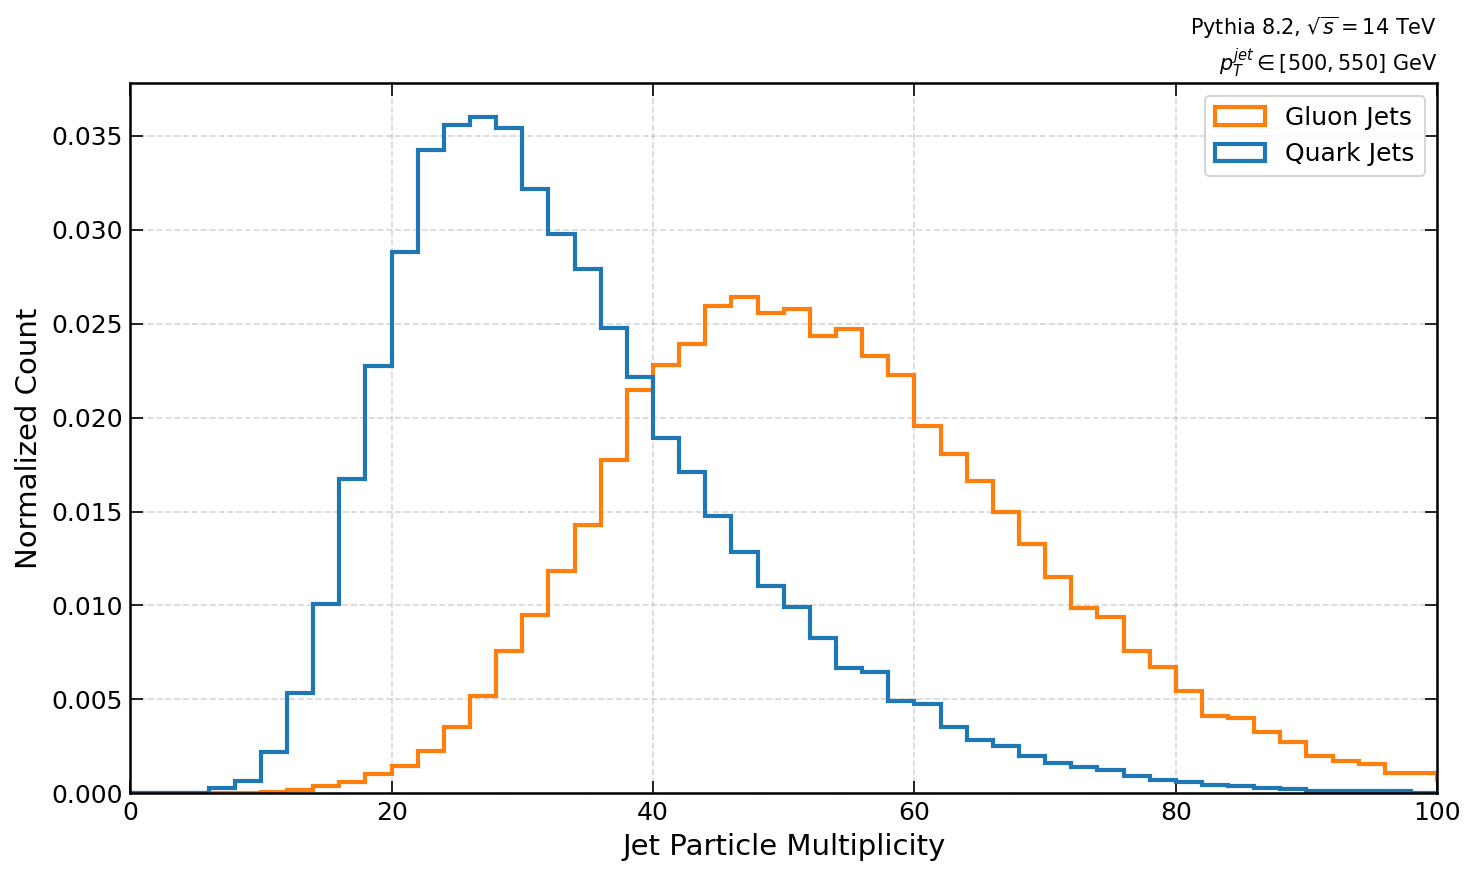

In [48]:
# Histogram
df_mult = df_reals.group_by(['jet_id', "target"]).agg(pl.len().alias("multiplicity"))

mult_g = df_mult.filter(pl.col('target') == 0)['multiplicity'].to_numpy()
mult_q = df_mult.filter(pl.col('target') == 1)['multiplicity'].to_numpy()

plt.figure()
bins_mult = np.arange(0, max_multiplicity, 2)
plt.hist(mult_g, 
            bins=bins_mult,
            histtype="step",
            lw=2,
            #alpha=0.6,
            label='Gluon Jets',
            color=G_COLOR,
            density=True)
plt.hist(mult_q, 
            bins=bins_mult,
            histtype="step",
            lw=2,
            #alpha=0.6,
            label='Quark Jets',
            color=Q_COLOR,
            density=True)

plt.xlabel(r'Jet Particle Multiplicity')
plt.ylabel('Normalized Count')
plt.xlim(0, 100)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.title("Pythia 8.2, $\sqrt{s} = 14$ TeV\n$p_T^{jet} \in [500, 550]$ GeV", 
            loc="right", fontsize=10)
plt.tight_layout()
plt.show()

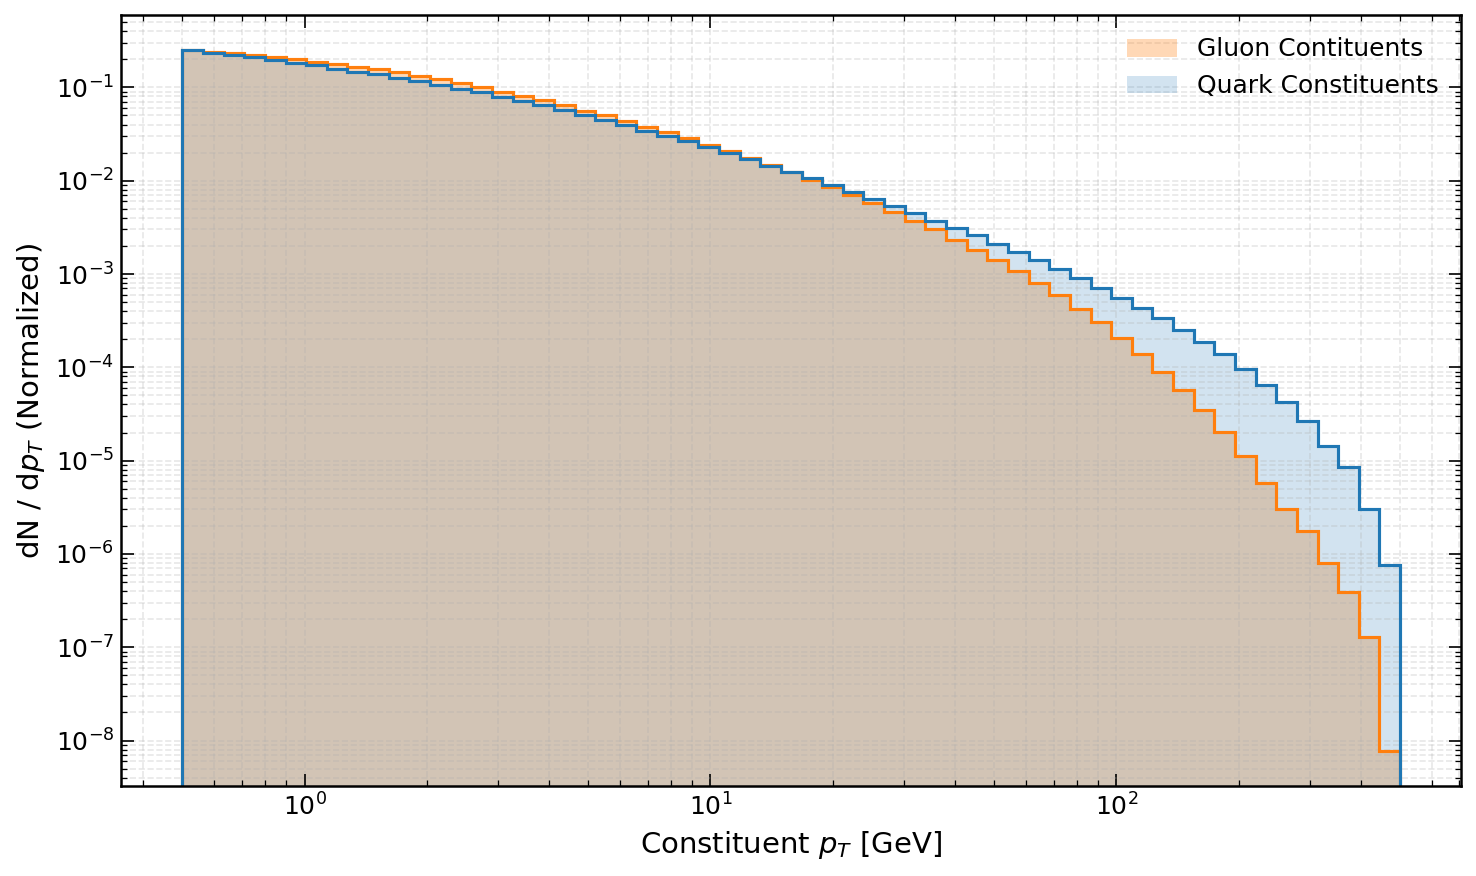

In [37]:
# Monmentum spectrum (log scale)
pt_g = df_reals.filter(pl.col('target') == 0)['pt'].to_numpy()
pt_q = df_reals.filter(pl.col('target') == 1)['pt'].to_numpy()

plt.figure()
bins_pt = np.logspace(np.log10(0.5), np.log10(500), 60)
plt.hist(pt_g, 
            bins=bins_pt,
            histtype="stepfilled",
            lw=2,
            alpha=0.3,
            label='Gluon Contituents',
            color=G_COLOR,
            density=True)
plt.hist(pt_g, bins=bins_pt, histtype="step", lw=1.5, color=G_COLOR, density=True)
plt.hist(pt_q, 
            bins=bins_pt,
            histtype="stepfilled",
            alpha=0.2,
            color=Q_COLOR,
            label="Quark Constituents",
            density=True)
plt.hist(pt_q, bins=bins_pt, histtype="step", lw=1.5, color=Q_COLOR, density=True)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Constituent $p_T$ [GeV]")
plt.ylabel("dN / d$p_T$ (Normalized)")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
#plt.savefig("constituent_pt.pdf", dpi=300)
plt.show()

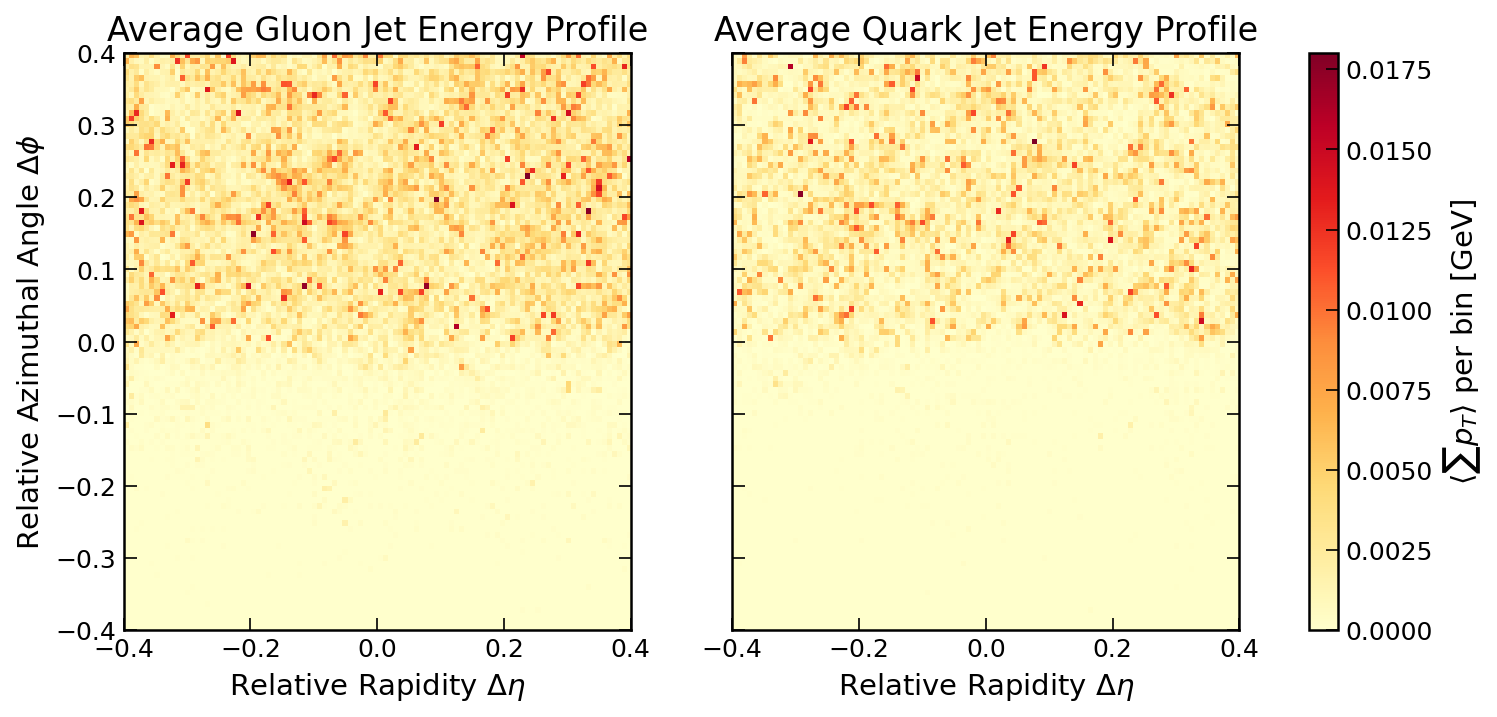

In [51]:
eta_reals = df_reals["eta"].to_numpy()
phi_reals = df_reals["phi"].to_numpy()
pt_reals = df_reals["pt"].to_numpy()
target_reals = df_reals["target"].to_numpy()

mask_g = (target_reals == 0)
mask_q = (target_reals == 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Algorithm range of the anti-kt Jets R = 0.4
grid_range = [[-0.4, 0.4], [-0.4, 0.4]]

# 2D histogram weighted by the pt of each particle (Energy Density)
hist_g, xedges, yedges = np.histogram2d(eta_reals[mask_g],
                                            phi_reals[mask_g],
                                            bins=100,
                                            range=grid_range,
                                            weights=pt_reals[mask_g])
hist_q, _, _ = np.histogram2d(eta_reals[mask_q],
                              phi_reals[mask_q],
                              bins=100,
                              range=grid_range,
                              weights=pt_reals[mask_q])

# Normalize by the total number of events to represent the "Average Jet"
hist_g /= (num_jets / 2)
hist_q /= (num_jets / 2)

im0 = ax[0].imshow(hist_g.T, 
                    extent=[-0.4, 0.4, -0.4, 0.4],
                    origin='lower',
                    cmap='YlOrRd',
                    aspect='auto')
ax[0].set_title("Average Gluon Jet Energy Profile")
ax[0].set_xlabel(r"Relative Rapidity $\Delta \eta$")
ax[0].set_ylabel(r"Relative Azimuthal Angle $\Delta \phi$")

im1 = ax[1].imshow(hist_q.T, 
                    extent=[-0.4, 0.4, -0.4, 0.4],
                    origin='lower',
                    cmap='YlOrRd',
                    aspect='auto')
ax[1].set_title("Average Quark Jet Energy Profile")
ax[1].set_xlabel(r"Relative Rapidity $\Delta \eta$")

# Unified color bar for interpreting deposited energy
fig.colorbar(im1, ax=ax.ravel().tolist(), label=r"$\langle \sum p_T \rangle$ per bin [GeV]")
#plt.savefig("jet_surface_heatmaps.pdf", dpi=300, bbox_inches='tight')
plt.show()

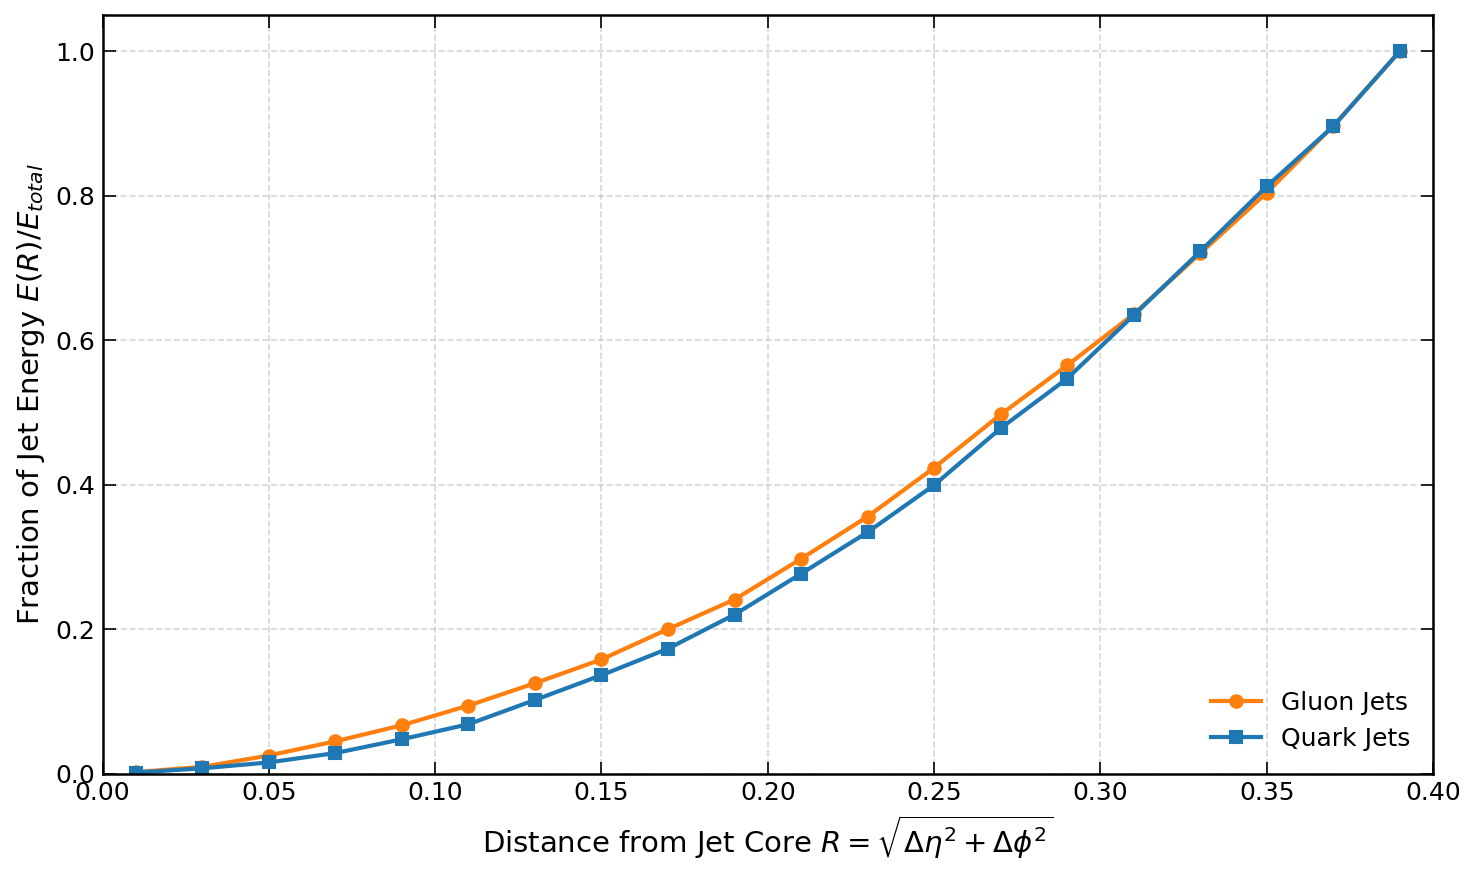

In [ ]:
df_radial = df_reals.with_columns(
    (pl.col("eta")**2 + pl.col("phi")**2).sqrt().alias("r")
)

# Create radial bins and centers for the profile plot
r_bins = np.linspace(0, 0.4, 21)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2

profile_q = []
profile_g = []

# Sum the p_T deposited in each concentric ring
for i in range(len(r_bins)-1):
    r_min, r_max = r_bins[i], r_bins[i+1]
    
    pt_sum = (df_radial.filter((pl.col("r") >= r_min) & (pl.col("r") < r_max))
              .group_by("target")
              .agg(pl.col("pt").sum())
              .sort("target"))
    
    # Safe handling if a bin is empty
    sum_g = pt_sum.filter(pl.col("target") == 0)["pt"].to_numpy()
    sum_q = pt_sum.filter(pl.col("target") == 1)["pt"].to_numpy()
    
    profile_g.append(sum_g[0] if len(sum_g) > 0 else 0)
    profile_q.append(sum_q[0] if len(sum_q) > 0 else 0)

# Convert to cumulative distribution profiles (Integrated Energy)
cum_profile_g = np.cumsum(profile_g) / np.sum(profile_g)
cum_profile_q = np.cumsum(profile_q) / np.sum(profile_q)

plt.figure()
plt.plot(r_centers, cum_profile_g, marker='o', ls='-', color=G_COLOR, label="Gluon Jets", lw=2)
plt.plot(r_centers, cum_profile_q, marker='s', ls='-', color=Q_COLOR, label="Quark Jets", lw=2)

plt.xlabel(r"Distance from Jet Core $R = \sqrt{\Delta \eta^2 + \Delta \phi^2}$")
plt.ylabel(r"Fraction of Jet Energy $E(R)/E_{total}$")
plt.xlim(0, 0.4)
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
#plt.savefig("jet_radial_profile.pdf", dpi=300)
plt.show()

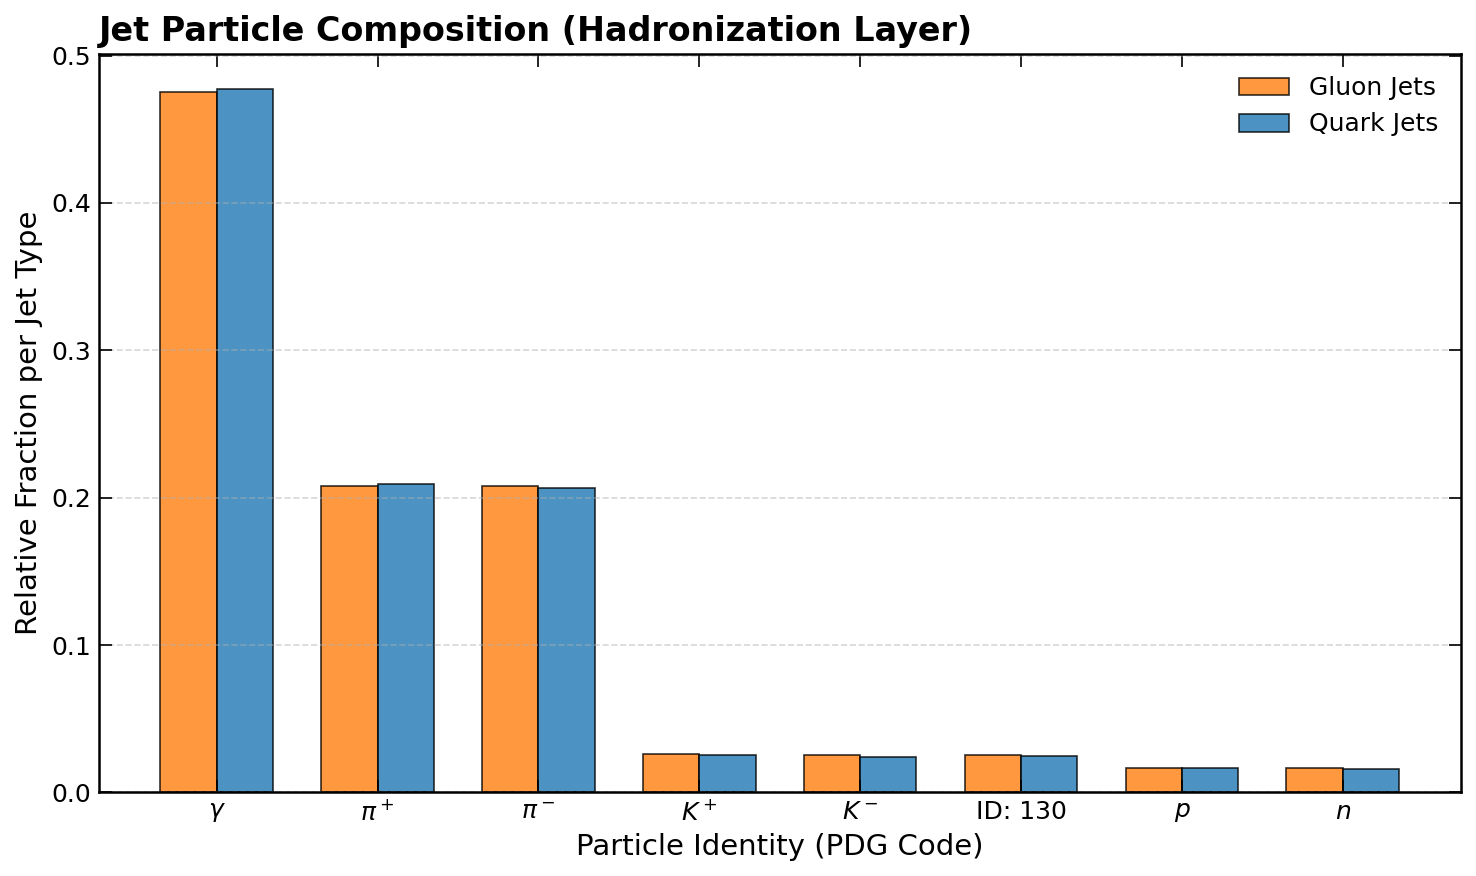

In [ ]:
df_pdg = pl.DataFrame({
    "pdgid": X[:, :, 3].reshape(-1),
    "target": labels
}).filter(pl.col("pdgid") != 0) # Remove padding

# Official Particle Data Group (PDG) translation dictionary
pdg_labels = {
    211: r"$\pi^+$",
    -211: r"$\pi^-$",
    111: r"$\pi^0$",
    22: r"$\gamma$",
    321: r"$K^+$",
    -321: r"$K^-$",
    2212: r"$p$",
    -2212: r"$\bar{p}$",
    11: r"$e^-$",
    -11: r"$e^+$",
    13: r"$\mu^-$",
    -13: r"$\mu^+$",
    2112: r"$n$",
    -2112: r"$\bar{n}$"
}

# Find the most abundant particles in the dataset dynamically
top_particles = (df_pdg.group_by("pdgid")
                 .len()
                 .sort("len", descending=True)
                 .head(8)["pdgid"]
                 .to_list())

# Group and calculate relative fractions by Jet type
df_counts = (df_pdg.filter(pl.col("pdgid").is_in(top_particles))
             .group_by(["target", "pdgid"])
             .len()
             .with_columns(
                 (pl.col("len") / pl.col("len").sum().over("target")).alias("fraction")
             ))

# ==========================================
# 2. RENDERING THE DISCRETE BAR CHART
# ==========================================
fig, ax = plt.subplots()

x_indexes = np.arange(len(top_particles))
bar_width = 0.35

# Extract the fractions in order to maintain consistency on the X-axis
frac_g = [df_counts.filter((pl.col("target") == 0) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]
frac_q = [df_counts.filter((pl.col("target") == 1) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]

# Draw the bars for Gluons and Quarks
ax.bar(x_indexes - bar_width/2, frac_g, bar_width, color=G_COLOR, alpha=0.8, edgecolor='black', linewidth=0.8, label="Gluon Jets")
ax.bar(x_indexes + bar_width/2, frac_q, bar_width, color=Q_COLOR, alpha=0.8, edgecolor='black', linewidth=0.8, label="Quark Jets")

# Map the names in LaTeX format on the X-axis
xtick_names = [pdg_labels.get(int(p), f"ID: {int(p)}") for p in top_particles]
ax.set_xticks(x_indexes)
ax.set_xticklabels(xtick_names, rotation=0)

ax.set_xlabel("Particle Identity (PDG Code)")
ax.set_ylabel("Relative Fraction per Jet Type")
ax.set_title("Jet Particle Composition (Hadronization Layer)", loc="left", fontweight="bold")
ax.grid(True, axis='y', linestyle="--", alpha=0.5)
ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig("jet_pdgid_composition.pdf", dpi=300)
plt.show()

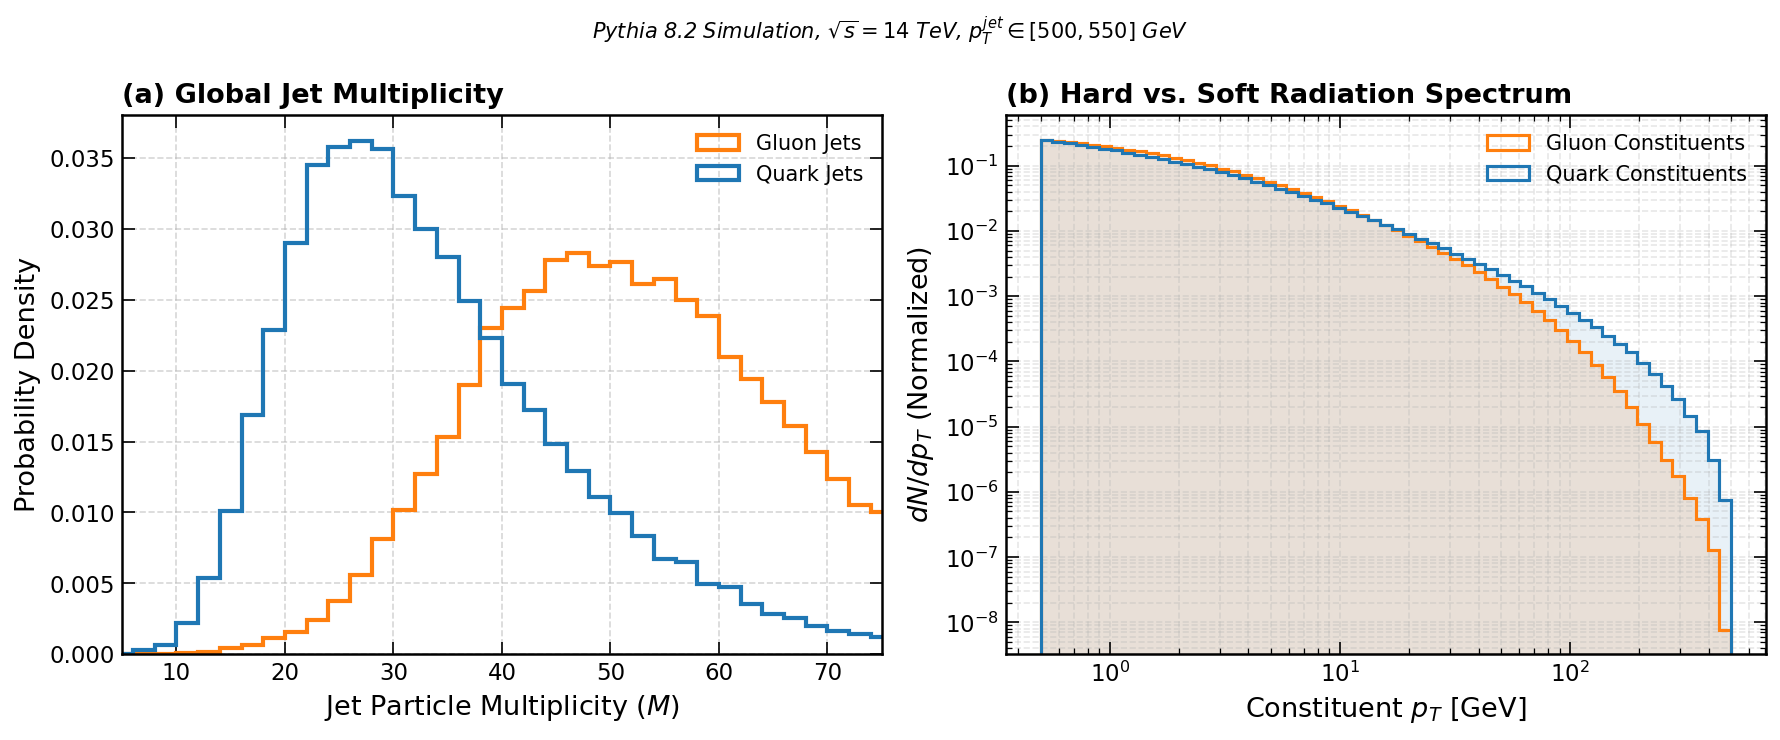

In [ ]:
# --- Style Configuration ---
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


# ==========================================
# PANEL 1: GLOBAL EVENT PROPERTIES (2 Subplots)
# ==========================================
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))

# --- Subplot A: Multiplicity Histogram ---
df_mult = df_reals.group_by(["jet_id", "target"]).agg(pl.len().alias("multiplicity"))
mult_g = df_mult.filter(pl.col("target") == 0)["multiplicity"].to_numpy()
mult_q = df_mult.filter(pl.col("target") == 1)["multiplicity"].to_numpy()

bins_mult = np.arange(0, 80, 2)
ax1[0].hist(mult_g, bins=bins_mult, histtype="step", lw=2, color=G_COLOR, label="Gluon Jets", density=True)
ax1[0].hist(mult_q, bins=bins_mult, histtype="step", lw=2, color=Q_COLOR, label="Quark Jets", density=True)

ax1[0].set_xlabel(r"Jet Particle Multiplicity ($M$)")
ax1[0].set_ylabel("Probability Density")
ax1[0].set_xlim(5, 75)
ax1[0].grid(True, linestyle="--", alpha=0.5)
ax1[0].legend(frameon=False)
ax1[0].set_title("(a) Global Jet Multiplicity", loc="left", fontweight="bold")

# --- Subplot B: Transverse Momentum Spectrum (Log-Scale) ---
pt_g = df_reals.filter(pl.col("target") == 0)["pt"].to_numpy()
pt_q = df_reals.filter(pl.col("target") == 1)["pt"].to_numpy()

bins_pt = np.logspace(np.log10(0.5), np.log10(500), 60)
ax1[1].hist(pt_g, bins=bins_pt, histtype="stepfilled", alpha=0.15, color=G_COLOR, density=True)
ax1[1].hist(pt_g, bins=bins_pt, histtype="step", lw=1.5, color=G_COLOR, label="Gluon Constituents", density=True)
ax1[1].hist(pt_q, bins=bins_pt, histtype="stepfilled", alpha=0.1, color=Q_COLOR, density=True)
ax1[1].hist(pt_q, bins=bins_pt, histtype="step", lw=1.5, color=Q_COLOR, label="Quark Constituents", density=True)

ax1[1].set_xscale("log")
ax1[1].set_yscale("log")
ax1[1].set_xlabel(r"Constituent $p_T$ [GeV]")
ax1[1].set_ylabel(r"$dN / dp_T$ (Normalized)")
ax1[1].grid(True, which="both", linestyle="--", alpha=0.3)
ax1[1].legend(frameon=False)
ax1[1].set_title("(b) Hard vs. Soft Radiation Spectrum", loc="left", fontweight="bold")

fig1.suptitle(r"Pythia 8.2 Simulation, $\sqrt{s} = 14$ TeV, $p_T^{jet} \in [500, 550]$ GeV", fontsize=10, y=0.98, style="italic")
plt.tight_layout()
#fig1.savefig("panel1_global_properties.pdf", dpi=300)
plt.show()

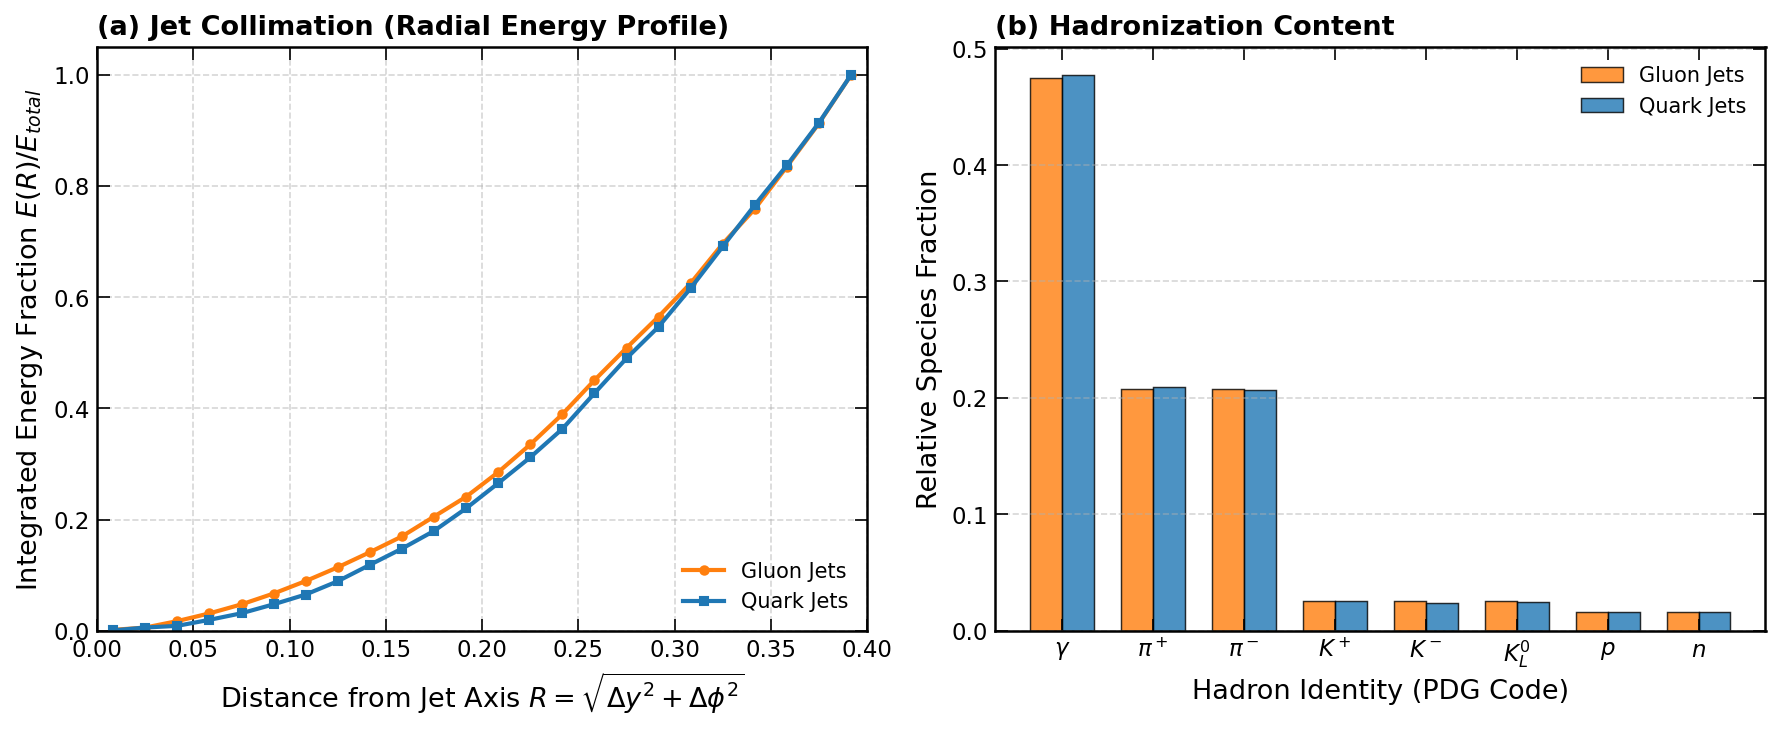

In [ ]:
# ==========================================
# PANEL 2
# ==========================================
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))

# --- Subplot A: Radial Energy Profile Limited to R=0.4 ---
df_radial = df_reals.with_columns(
    (pl.col("eta")**2 + pl.col("phi")**2).sqrt().alias("r")
)

r_bins = np.linspace(0, 0.4, 25)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
profile_q, profile_g = [], []

for i in range(len(r_bins)-1):
    r_min, r_max = r_bins[i], r_bins[i+1]
    pt_sum = (df_radial.filter((pl.col("r") >= r_min) & (pl.col("r") < r_max))
              .group_by("target").agg(pl.col("pt").sum()).sort("target"))
    
    sum_g = pt_sum.filter(pl.col("target") == 0)["pt"].to_numpy()
    sum_q = pt_sum.filter(pl.col("target") == 1)["pt"].to_numpy()
    profile_g.append(sum_g[0] if len(sum_g) > 0 else 0)
    profile_q.append(sum_q[0] if len(sum_q) > 0 else 0)

cum_profile_g = np.cumsum(profile_g) / np.sum(profile_g)
cum_profile_q = np.cumsum(profile_q) / np.sum(profile_q)

ax2[0].plot(r_centers, cum_profile_g, marker='o', ls='-', color=G_COLOR, label="Gluon Jets", lw=2, markersize=4)
ax2[0].plot(r_centers, cum_profile_q, marker='s', ls='-', color=Q_COLOR, label="Quark Jets", lw=2, markersize=4)
ax2[0].set_xlabel(r"Distance from Jet Axis $R = \sqrt{\Delta y^2 + \Delta \phi^2}$")
ax2[0].set_ylabel(r"Integrated Energy Fraction $E(R)/E_{total}$")
ax2[0].set_xlim(0, 0.4)
ax2[0].set_ylim(0, 1.05)
ax2[0].grid(True, linestyle="--", alpha=0.5)
ax2[0].legend(frameon=False, loc="lower right")
ax2[0].set_title("(a) Jet Collimation (Radial Energy Profile)", loc="left", fontweight="bold")

# --- Subplot B: Chemical Composition by PDGID (Top 8 Including K_L^0) ---
pdg_labels = {
    211: r"$\pi^+$", 
    -211: r"$\pi^-$", 
    111: r"$\pi^0$", 
    22: r"$\gamma$",
    130: r"$K_L^0$", 
    321: r"$K^+$", 
    -321: r"$K^-$", 
    2212: r"$p$",
    2112: r"$n$"
}
top_particles = (df_pdg.group_by("pdgid")
                 .len()
                 .sort("len", descending=True)
                 .head(8)["pdgid"]
                 .to_list())

df_counts = (df_reals.filter(pl.col("pdgid").is_in(top_particles))
             .group_by(["target", "pdgid"]).len()
             .with_columns((pl.col("len") / pl.col("len").sum().over("target")).alias("fraction")))

# Ensure all (target, pdgid) combinations exist to avoid IndexError in [0] access
all_pairs = (
    pl.DataFrame({"target": [0, 1]})
    .join(pl.DataFrame({"pdgid": [float(p) for p in top_particles]}), how="cross")
)

df_counts = (
    all_pairs
    .join(df_counts, on=["target", "pdgid"], how="left")
    .with_columns(
        pl.col("len").fill_null(0),
        pl.col("fraction").fill_null(0.0),
    )
)

frac_g = [df_counts.filter((pl.col("target") == 0) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]
frac_q = [df_counts.filter((pl.col("target") == 1) & (pl.col("pdgid") == p))["fraction"].to_list()[0] for p in top_particles]

x_indexes = np.arange(len(top_particles))
bar_width = 0.35

ax2[1].bar(x_indexes - bar_width/2, frac_g, bar_width, color=G_COLOR, alpha=0.8, edgecolor='black', lw=0.7, label="Gluon Jets")
ax2[1].bar(x_indexes + bar_width/2, frac_q, bar_width, color=Q_COLOR, alpha=0.8, edgecolor='black', lw=0.7, label="Quark Jets")

xtick_names = [pdg_labels.get(int(p), f"ID: {int(p)})") for p in top_particles]
ax2[1].set_xticks(x_indexes)
ax2[1].set_xticklabels(xtick_names)
ax2[1].set_xlabel("Hadron Identity (PDG Code)")
ax2[1].set_ylabel("Relative Species Fraction")
ax2[1].grid(True, axis='y', linestyle="--", alpha=0.5)
ax2[1].legend(frameon=False)
ax2[1].set_title("(b) Hadronization Content", loc="left", fontweight="bold")

plt.tight_layout()
#fig2.savefig("panel2_geometry_and_flavor.pdf", dpi=300)
plt.show()

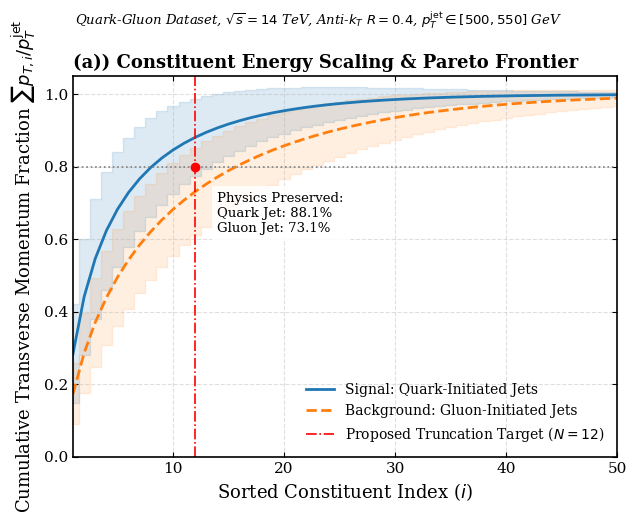

In [ ]:
# ==============================================================================
# Style Configuration
# ==============================================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "font.family": "serif"
})

QUARK_COLOR = '#1f77b4'  # Blue for the Signal (Quark Jets)
GLUON_COLOR = '#ff7f0e'  # Orange for the Background (Gluon Jets)

# ==============================================================================
# KINEMATIC PROCESSING OF PARETO (QUARK-GLUON DATASET)
# ==============================================================================
# Extract the first column (index 0) corresponding to the raw p_T of the 139 particles
pt_matrix = X[:, :, 0]
y_target = y  # 1: Quark Jet, 0: Gluon Jet

# Ensure that the constituents are sorted from highest to lowest p_T per Jet
pt_matrix_sorted = np.sort(pt_matrix, axis=1)[:, ::-1]

# Compute the cumulative sum along the particle axis (columns)
cumulative_pt = np.cumsum(pt_matrix_sorted, axis=1)

# The last cumulative element (column 139) represents the total p_T of the complete Jet
total_pt = cumulative_pt[:, -1]
total_pt_safe = np.where(total_pt == 0, 1.0, total_pt)  # Safe against division by zero

# Divide each step by the total jet p_T to obtain the fraction (scale 0 to 1)
pt_fraction_matrix = cumulative_pt / total_pt_safe[:, None]

# Segregate the profile matrices according to the true class of the collider
quark_profiles = pt_fraction_matrix[y_target == 1]
gluon_profiles = pt_fraction_matrix[y_target == 0]

# Calculate the mean and standard deviation for each particle index
mean_quark = np.mean(quark_profiles, axis=0)
std_quark = np.std(quark_profiles, axis=0)

mean_gluon = np.mean(gluon_profiles, axis=0)
std_gluon = np.std(gluon_profiles, axis=0)

# The X-axis denotes the actual count of integrated particles (1 to 139)
particle_indices = np.arange(1, 140)

# ==============================================================================
# CONSTRUCTION AND RENDERING OF THE DIAGRAM
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.5, 5.2))

# Signal curve (Quark) with 1-sigma statistical uncertainty shading
ax.plot(particle_indices, mean_quark, color=QUARK_COLOR, lw=2.0, label=r"Signal: Quark-Initiated Jets")
ax.fill_between(particle_indices, mean_quark - std_quark, mean_quark + std_quark, 
                color=QUARK_COLOR, alpha=0.15, step="mid")

# Background curve (Gluon) with 1-sigma statistical uncertainty shading
ax.plot(particle_indices, mean_gluon, color=GLUON_COLOR, lw=2.0, label="Background: Gluon-Initiated Jets", linestyle="--")
ax.fill_between(particle_indices, mean_gluon - std_gluon, mean_gluon + std_gluon, 
                color=GLUON_COLOR, alpha=0.12, step="mid")

# --- CRITICAL INDICATORS OF THE TRUNCATION THRESHOLD ---
# We look for the average index where the combined dataset crosses 80% of net p_T
mean_combined = np.mean(pt_fraction_matrix, axis=0)
N_corte = np.argmax(mean_combined >= 0.80) + 1  # Optimal point determined by the energy elbow
fraccion_en_corte_quark = mean_quark[N_corte - 1]

# Guide lines for geometric intersection at the cutoff point
ax.axhline(y=0.80, color='gray', linestyle=':', lw=1.2)
ax.axvline(x=N_corte, color='red', linestyle='-.', lw=1.2, 
           label=f"Proposed Truncation Target ($N={N_corte}$)")

# Visual collision node at the boundary
ax.plot(N_corte, 0.80, marker='o', color='red', markersize=6)

# Explanatory text box with the exact percentage of physics preserved
texto_física = f"Physics Preserved:\nQuark Jet: {fraccion_en_corte_quark*100:.1f}%\nGluon Jet: {mean_gluon[N_corte-1]*100:.1f}%"
ax.text(N_corte + 2, 0.80 - 0.18, texto_física, 
        fontsize=9.5, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

# --- AXIS FORMATTING STYLE ---
ax.set_xlabel("Sorted Constituent Index ($i$)")
ax.set_ylabel(r"Cumulative Transverse Momentum Fraction $\sum p_{T,i} / p_{T}^{\mathrm{jet}}$")

# Strategic zoom in the "elbow" region to appreciate the saturation of information
ax.set_xlim(1, 50)
ax.set_ylim(0.0, 1.05)

# Title of the subplot and detector metadata in the upper area
ax.set_title("(a)) Constituent Energy Scaling & Pareto Frontier", loc="left", fontweight="bold")
fig.suptitle(r"Quark-Gluon Dataset, $\sqrt{s} = 14$ TeV, Anti-$k_T$ $R=0.4$, $p_T^{\mathrm{jet}} \in [500, 550]$ GeV", 
             fontsize=9.5, y=0.98, style="italic")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
# fig.savefig("pareto_frontier_quark_gluon.pdf", dpi=300)
plt.show()